## 1. 导包

In [9]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from config import config
from env import GridWorld
from rollout import ReplayBuffer, uniform_rollout
from runner import DQN_Runner
from visualize import plot_policy, plot_training_curve

## 2. 参数配置与经验采集

In [10]:
cfg = config(
        # env config
        row_num=5,col_num=5,
        reward={
            "boundary":-10,
            "forbidden":-10,
            "target":10,
            "blank":0
        },
        # 0为空白，1为禁止，2为目标
        grid=[
            [0,0,0,0,1],
            [0,1,1,0,2],
            [1,0,1,0,0],
            [0,1,2,1,0],
            [0,1,0,0,0]
        ],

        # rl config
        epsilon=0.1,
        gamma=0.90,
        lr=5e-4,
        batch_size=512,
        target_update_interval=100,
        train_iteration=20000,
        device="cuda:0",
        # rollout config
        rollout_steps=10000,
        # random
        seed=123456,
        # net config
        input_dim=2,
        output_dim=5,
        hidden_dim=[100,50]
)

random.seed(cfg.rand.seed)
np.random.seed(cfg.rand.seed)
torch.manual_seed(cfg.rand.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.rand.seed)

if cfg.rollout.steps < cfg.rl.batch_size:
    raise ValueError("rollout steps must be at least as large as batch_size")

env = GridWorld(cfg)
replay_buffer = ReplayBuffer(
    capacity=cfg.rollout.steps,
    seed=cfg.rand.seed,
)
rollout_return, rollout_rewards = uniform_rollout(
    env=env,
    cfg=cfg,
    replay_buffer=replay_buffer,
)

print(f"replay buffer size: {len(replay_buffer)}")
print(f"rollout return: {rollout_return:.2f}")

replay buffer size: 10000
rollout return: -38120.00


## 3. DQN 训练

In [11]:
runner = DQN_Runner(cfg)
losses = []
report_interval = max(1, cfg.rl.train_iteration // 10)

for iteration in range(1, cfg.rl.train_iteration + 1):
    loss = runner.train_step(replay_buffer)
    losses.append(loss)

    if iteration == 1 or iteration % report_interval == 0:
        print(f"iteration={iteration:4d}  loss={loss:.6f}")

print(f"device: {runner.device}")

iteration=   1  loss=54.825813
iteration=2000  loss=29.922398
iteration=4000  loss=24.718523
iteration=6000  loss=17.687683
iteration=8000  loss=12.572540
iteration=10000  loss=8.882959
iteration=12000  loss=4.481935
iteration=14000  loss=2.693792
iteration=16000  loss=2.215591
iteration=18000  loss=2.266614
iteration=20000  loss=1.787786
device: cuda:0


## 4. 训练结果可视化

greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):
[[1 1 1 2 2]
 [0 1 1 1 4]
 [1 1 2 0 0]
 [1 1 4 3 0]
 [1 1 0 3 0]]
figures saved to: D:\My Knowledge\AI algorithm&architecture\Reinforcement-Learning\output


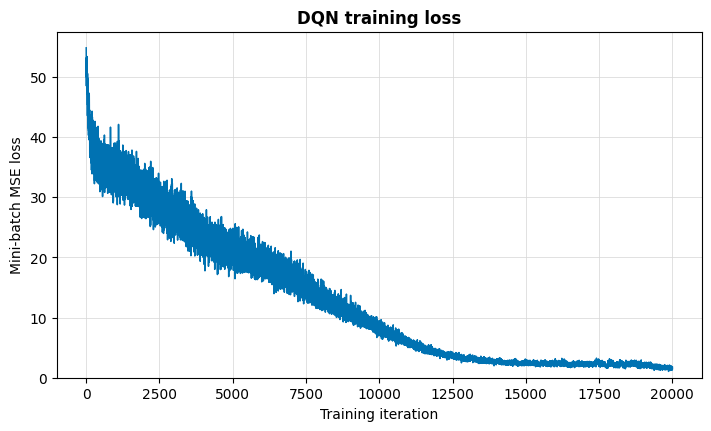

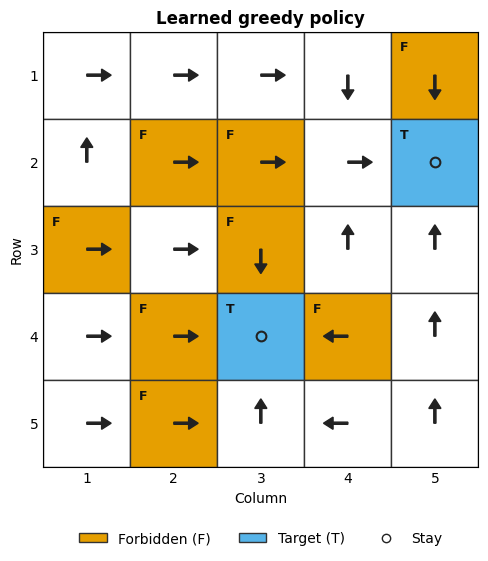

In [12]:
workspace = Path.cwd().parent if Path.cwd().name == 'code' else Path.cwd()
output_dir = workspace / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

plot_training_curve(
    losses,
    save_path=output_dir / 'dqn_training_loss.png',
    show=False,
)
_, _, policy, q_values = plot_policy(
    runner,
    cfg,
    save_path=output_dir / 'dqn_greedy_policy.png',
    show=False,
)

print("greedy policy (0=up, 1=right, 2=down, 3=left, 4=stay):")
print(policy)
print(f"figures saved to: {output_dir.resolve()}")
plt.show()